IMPLEMENTAZIONE PRATICA DI UNA GAN CON PYTORCH

- Custom Trainin Loop: controllo totale sui gradienti
- Label Smoothing: stabilizzare il discriminatore
- Architettura Dense: costruire G e D con nn.Module

Gestione manuale dei gradienti
Perchè Pytorch?
PyTorch ci permette di decidere come e quando aggioranre i pesi. Ci permette di entrare dentro il ciclo di addestramento.
In una GAN non possiamo usare un semplice .model.fit(): dobbiamo orchestrare una danza precisa in cui il Discriminatore e il Generatore si aslternano nel processo di ottimizzazione.

Come di traduce questa danza in passi di codice?

Aggiornamenti Alternati
Dall'errore all'ottimizzazione dei parametri
- Ad ogni iterazione calcoliamo prima la perdita del Discriminatore sia su dati reali sia su sintetici e quindi impara a distinguere, usiamo la binary cross entropy per dargli un voto.
- Eseguiamo loss.backward() e optimizer.step() per D, mantentendo G congelato.
- Successivamente, generiamo nuovi dati e calcoliamo la perdita G basandoci sulla risposta di D
- L'ottimizzazione di G richiede che il Discriminatore sia trattato come una funzione fissa ma differenziale.

Per far si che questo processo arrivi a destrinazione dobbiamo gestire bene i gradienti.

Flusso di Calcolo in PyTorch
E' fondamentale chiamare optimizer.zero_grad() prima di ogni backward per evitare l'accumulo dei gradienti tra D e G
In Pytorch ogni operazione crea un file invisibile che collega i risultati ai pesi. 
Il grafo computazionale viene ricostruito dinamicamente, ogni volta, permettendo a G di ricevere feedback dalla valutazione di D
Utilizziamo due istanze diverse di torch.optim, spesso con learning rate differenti per bilanciare la sfida.

Ma perchè preferiamo questo controllo manuale rispetto a un sistema automatico'

La Flessibilità del Manual Loop
Perchè non usare astrazioni di alto livello?
il controllo manuale ci permette di introdurre euristiche come addestrare il discriminatore più volte rispetto al generatore per ogni step. 
A volte il Discriminatore è troppo lento e il Generatore scappa via, imparando a generare immagini sfuocate che inganno un poliziotto miope. Abbiamo la possibilità di addestrare il Discriminatore 5 volte (pes esempio) ed una volta il Generatore. Quindi PyTorch permette di provare strategie che un tools standard non permetterebbe.
Questa granularità è ciò che rende PyTorch lo strumento standard per la ricerca avanzata sui modelli generativi.

Ma anche con il controllo totale il Discriminatore può diventare un problema

Label Smoothing
Regolarizzare l'eccessiva sicurezza del critico
Immagina un poliziotto che è talmente arrogante e sicuro di se da non accettare nessuna sfumatura.
Uno dei problemi principali delle GAN è che il Discriminatore può diventare perfetto troppo velocemente (e da solo 0 o 1 assoluti), i gradienti diventano vuoti. Il Generatore si trova davanti a un muro di gomma, non riceve più informazioni utili su come miglioare, ma solo un secco rifiuto.
Lo Smoothing serve a smussare questa arroganza.
Il Label Smoothing è una tecnica elegante per 'ammorbidire' i target e mantenere il processo di apprendimento fluido e costante.

Come trasformiamo il giudizio binario del poliziotto troppo sicuro di se in un giudizio utilile?

Soft Targets
Ridurre l'hard-classification
- Invece di usare 1.0 per le immagini reali, usiamo un valore come 0.9.
- Questo impedisce alla funzione Sigmoide di saturare nella zone piatte dove il gradiente è prossimo allo zero. Maneniamo la rete in una zona di incertezza produttiva.
- Il Generatore riceve segnali più informativi su 'come' migliorare invece di un secco rifiuto. Non gli viene detto solo 'hai sbagliato' ma anche informazioni su come muoversi per miglioare.
- La tecnica agisce come una forma di regolarizzazione che riduce la vulnerabilità del sistema alle oscillazioni.

Questa tecnica è la nostra assicurazione contro la morte dei gradienti

Stabilità dei Gradienti.
Se D è troppo sicuro, la derivate della sigmoide diventa infinitesima, 'uccidendo' l'apprendimento di G (saturazione della Sigmoide)
Smoothing impedisce a D di basarsi su pochi pixel discriminante, forzando a guardare a feature più olistico, cercando pattern più complessi più utili al Generatore (prevenzione dell'overfitting).
Spesso di applica lo smoothing solo alle etichette 'reali' per evitare di confondere eccessivamente il modello (One-sided Smoothing).

Ma cosa stiamo effettivamente perdendo rinunciando alla precisione assoluta?

Dinamica dell'Errore.
Un compromesso necessario
Rinunciando alla precisione assoluta del target (1.0), guadagniamo una stabilità che è vitale per evitare il fallimento del training.
Questa tecnica è diventata una 'best practice' universale dopo i primi lavori di Salimans e colleghi nel 2016, questo perhcè risolve il problema della GAN dell'instabilità cronica.

Costruiamo la struttura fisica delle nostre reti

Architettura Dense
Modellare G e D con il Multi-Layer Perceptron
Invece di usare convoluzioni complicate, trattiamo le immagini come un lungo elenco di 784 valori. Questo ci permette di non perderci su dettagli spaziali più avanzati che fanno parte di strutture più avanzate .
Inizieremo costruendo una GAN basata su strati completamente connessi per comprendere il flusso dei dati senza la complessità delle convoluzioni.
Con la classe nn.Module di PyTorch definiamo le trasformazioni lineari e le funzioni di attivazione non lineari.

Useremo nn.Module e nn.Linear
- Il Generatore parte dal rumore (un vettore latente) e lo trasforma in un vettore piatto di dimensione 784
- Il Discriminatore esegue l'operazione inversa, comprime l'informazione, riducendo i 784 pixel a un singolo valore di probabilità
- Le funzioni di attivazione come LeakyReLU sono preferite per evitare il problema dei neuroni morti.
- La struttura modulare permette di testare facilmente divese profondità e larghezze dei layer

Configurazione dei Layer
Il rumore in ingresso è il DNA della nostra generazione.
Solitamente usiamo 100 numeri casuali che rappresentano lo spazio delle possibilità (input Noise).
In uscita dal Generatore (ultimo layer) useremo la 'Tanh' per mappare l'output in un intervallo centrato in [-1,1] (output mapping).
Nel Discriminatore la LeakyReLU permettere il passaggio di piccoli segnali (gradienti) anche quando l'input sembra chiaramente falso (è negativo), mantenendo sempre vivo il dialogo di feedback con G.

Ma questa architettura semplice ha dei limiti che dobbiamo conoscere.

Limiti Del Modello Dense
Verso la visione artificiale.
Sebbene potenti, le reti Dense perdono l'informazione spaziale dei pixel (vicinanza).
Per le GAN un pixel in alto a sinistra e uno al centro, sono solo numeri isolati in una lista. Perdiamo il concetto di geometria di un'immagine.
Questa implementazione è il gradino necessario per capire la logica prima di passare alle DCGAN convoluzionali che vedremo presto.
Passare alle versione più avanzate (DCGAN) è semplice una volta capite le GAN perchè la logica resta identica.

100%|██████████| 26.4M/26.4M [00:04<00:00, 5.96MB/s]
100%|██████████| 29.5k/29.5k [00:00<00:00, 3.59MB/s]
100%|██████████| 4.42M/4.42M [00:01<00:00, 3.15MB/s]
100%|██████████| 5.15k/5.15k [00:00<?, ?B/s]


Training su cpu iniziato...
Epoca [1/20] Loss D: 1.0472 | Loss G: 1.7404
Epoca [2/20] Loss D: 1.1387 | Loss G: 1.2486
Epoca [3/20] Loss D: 1.0830 | Loss G: 1.3990
Epoca [4/20] Loss D: 1.2780 | Loss G: 1.0568
Epoca [5/20] Loss D: 1.2088 | Loss G: 1.3196
Epoca [6/20] Loss D: 1.3050 | Loss G: 1.0305
Epoca [7/20] Loss D: 1.2403 | Loss G: 1.2922
Epoca [8/20] Loss D: 1.2339 | Loss G: 1.0368
Epoca [9/20] Loss D: 1.3475 | Loss G: 1.1542
Epoca [10/20] Loss D: 1.3313 | Loss G: 1.1479
Epoca [11/20] Loss D: 1.2839 | Loss G: 1.0630
Epoca [12/20] Loss D: 1.2513 | Loss G: 0.9868
Epoca [13/20] Loss D: 1.3534 | Loss G: 0.9354
Epoca [14/20] Loss D: 1.3555 | Loss G: 0.9204
Epoca [15/20] Loss D: 1.2861 | Loss G: 0.9634
Epoca [16/20] Loss D: 1.3598 | Loss G: 0.9788
Epoca [17/20] Loss D: 1.3674 | Loss G: 1.0962
Epoca [18/20] Loss D: 1.3012 | Loss G: 0.9596
Epoca [19/20] Loss D: 1.2874 | Loss G: 0.9295
Epoca [20/20] Loss D: 1.2933 | Loss G: 0.9889


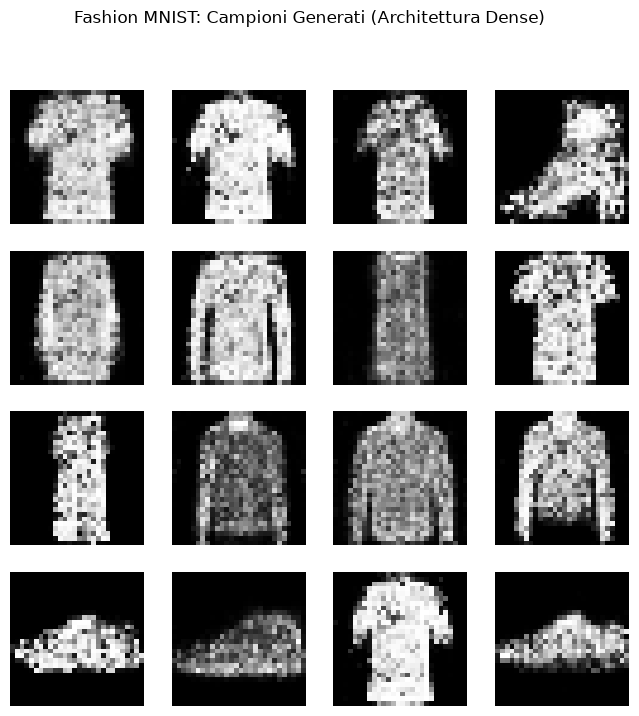

: 

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt

# --- 1. CONFIGURAZIONE E PREPARAZIONE DATI ---
# Selezioniamo la GPU se disponibile per velocizzare il calcolo, altrimenti usiamo la CPU.
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Iperparametri del modello
latent_dim = 100    # Dimensione del vettore di rumore casuale in ingresso al generatore
lr = 0.0002         # Learning rate, valore basso per stabilizzare l'addestramento della GAN
batch_size = 64     # Numero di immagini processate in ogni iterazione

# Definizione delle trasformazioni per le immagini.
# È cruciale normalizzare le immagini nel range [-1, 1] perché il Generatore usa Tanh come attivazione finale.
# Tanh produce output tra -1 e 1, quindi i dati reali devono avere lo stesso intervallo per il confronto.
transform = transforms.Compose([
    transforms.ToTensor(),                # Converte l'immagine in un tensore PyTorch
    transforms.Normalize((0.5,), (0.5,))  # Normalizza da [0, 1] a [-1, 1]: (valore - 0.5) / 0.5
])

# Carichiamo il dataset FashionMNIST.
# Il DataLoader gestisce il caricamento in batch e il mescolamento (shuffle) dei dati ad ogni epoca.
train_loader = DataLoader(
    datasets.FashionMNIST('.', train=True, download=True, transform=transform),
    batch_size=batch_size, shuffle=True
)

# --- 2. DEFINIZIONE DELL'ARCHITETTURA ---

# Il Generatore (G) è una rete neurale che crea immagini a partire da rumore casuale.
# Obiettivo: Imbrogliare il Discriminatore facendogli credere che le immagini generate siano reali.
class Generator(nn.Module):
    def __init__(self):
        super().__init__()
        # Struttura: Una serie di strati lineari (Fully Connected) che aumentano la dimensione
        # dal vettore latente (100) fino alla dimensione dell'immagine appiattita (784 = 28x28).
        self.main = nn.Sequential(
            nn.Linear(latent_dim, 256),
            nn.LeakyReLU(0.2),  # LeakyReLU permette un piccolo gradiente anche per valori negativi, evitando neuroni morti
            nn.Linear(256, 512),
            nn.LeakyReLU(0.2),
            nn.Linear(512, 1024),
            nn.LeakyReLU(0.2),
            nn.Linear(1024, 784), # 784 corrisponde ai pixel totali di un'immagine 28x28
            nn.Tanh() # Tanh schiaccia l'output tra -1 e 1, allineandolo alla normalizzazione dei dati reali
        )

    def forward(self, x):
        # Passa il rumore attraverso la rete e rimodella l'uscita in formato immagine (Batch, Canali, Altezza, Larghezza)
        return self.main(x).view(-1, 1, 28, 28)

# Il Discriminatore (D) è un classificatore binario.
# Obiettivo: Distinguere tra immagini reali (dal dataset) e immagini false (create dal Generatore).
class Discriminator(nn.Module):
    def __init__(self):
        super().__init__()
        # Struttura: Comprime l'immagine appiattita (784) in un singolo valore di probabilità.
        self.main = nn.Sequential(
            nn.Linear(784, 512),
            nn.LeakyReLU(0.2),
            nn.Linear(512, 256),
            nn.LeakyReLU(0.2),
            nn.Linear(256, 1),
            nn.Sigmoid() # Sigmoid produce un valore tra 0 e 1 (0 = Falso, 1 = Reale)
        )

    def forward(self, x):
        # Appiattisce l'immagine in un vettore 1D e la passa attraverso la rete
        return self.main(x.view(-1, 784))

# Inizializzazione delle reti e spostamento sul dispositivo (CPU o GPU)
netG = Generator().to(device)
netD = Discriminator().to(device)

# Ottimizzatori: Adam è standard per le GAN.
# Betas (0.5, 0.999) sono valori specifici che aiutano a stabilizzare l'addestramento adversarial.
optimizerD = optim.Adam(netD.parameters(), lr=lr, betas=(0.5, 0.999))
optimizerG = optim.Adam(netG.parameters(), lr=lr, betas=(0.5, 0.999))

# Funzione di perdita: Binary Cross Entropy Loss.
# Adatta per problemi di classificazione binaria (Vero/Falso).
criterion = nn.BCELoss()

# --- 3. LOOP DI ADDESTRAMENTO ---
# In questa fase, G e D competono in un gioco a somma zero.
epochs = 20
print(f"Training su {device} iniziato...")

for epoch in range(epochs):
    # Iteriamo su ogni batch di immagini reali dal dataset
    for i, (real_images, _) in enumerate(train_loader):
        b_size = real_images.size(0) # Dimensione del batch corrente
        real_images = real_images.to(device)

        # -----------------------------------------------------------
        # FASE A: ADDESTRAMENTO DEL DISCRIMINATORE
        # Obiettivo: Massimizzare la capacità di distinguere Reale da Falso
        # -----------------------------------------------------------
        netD.zero_grad() # Azzeriamo i gradienti accumulati nel passo precedente
        
        # 1. Addestramento con immagini REALI
        # Creiamo le etichette per il "Vero". Usiamo Label Smoothing (0.9 invece di 1.0).
        # Questo riduce l'overconfidence del Discriminatore e stabilizza il training.
        label_real = torch.full((b_size, 1), 0.9, device=device)
        
        output_real = netD(real_images)              # D analizza le immagini reali
        lossD_real = criterion(output_real, label_real) # Calcoliamo l'errore rispetto all'etichetta "Vero" (0.9)
        lossD_real.backward()                        # Calcoliamo i gradienti per la parte reale

        # 2. Addestramento con immagini FALSE
        # Generiamo rumore casuale
        noise = torch.randn(b_size, latent_dim, device=device)
        fake_images = netG(noise)                    # G genera immagini false dal rumore
        label_fake = torch.full((b_size, 1), 0.0, device=device) # Etichette per il "Falso" (0.0)
        
        # Passiamo le immagini false a D.
        # IMPORTANTE: .detach() scollega il tensore dal grafo computazionale del Generatore.
        # In questa fase vogliamo aggiornare solo D, non G. Senza detach, il gradiente risalirebbe fino a G.
        output_fake = netD(fake_images.detach())
        lossD_fake = criterion(output_fake, label_fake) # Calcoliamo l'errore rispetto all'etichetta "Falso" (0.0)
        lossD_fake.backward()                        # Calcoliamo i gradienti per la parte falsa

        # Aggiorniamo i pesi del Discriminatore
        lossD = lossD_real + lossD_fake              # Somma delle perdite (solo per log)
        optimizerD.step()

        # -----------------------------------------------------------
        # FASE B: ADDESTRAMENTO DEL GENERATORE
        # Obiettivo: Massimizzare la probabilità che D sbagli (classifichi Falso come Reale)
        # -----------------------------------------------------------
        netG.zero_grad() # Azzeriamo i gradienti
        
        # Rigeneriamo le etichette, ma questa volta "ingannevoli".
        # Vogliamo che il Generatore impari a produrre immagini che D classifica come Reali (0.9).
        label_real_for_g = torch.full((b_size, 1), 0.9, device=device)
        
        # Passiamo di nuovo le immagini false a D (questa volta senza detach!)
        # Vogliamo che il gradiente fluisca attraverso D fino a G, per dire a G come migliorare.
        output_g = netD(fake_images) 
        
        lossG = criterion(output_g, label_real_for_g) # Errore: quanto le immagini false sono lontane dall'essere "Reali"
        lossG.backward() # Calcoliamo i gradienti (che arriveranno fino ai pesi di G)
        optimizerG.step() # Aggiorniamo i pesi del Generatore

    # Stampiamo le perdite alla fine di ogni epoca per monitorare il progresso
    print(f"Epoca [{epoch+1}/{epochs}] Loss D: {lossD.item():.4f} | Loss G: {lossG.item():.4f}")

# --- 4. VISUALIZZAZIONE DEI RISULTATI ---
# Disabilitiamo il calcolo dei gradienti per l'inferenza (risparmia memoria e calcolo)
with torch.no_grad():
    sample_noise = torch.randn(16, latent_dim, device=device) # Generiamo 16 vettori di rumore
    generated = netG(sample_noise).cpu()                      # Generiamo le immagini e le portiamo in CPU per mostrarle

# Creiamo una griglia 4x4 per visualizzare le immagini generate
plt.figure(figsize=(8, 8))
for i in range(16):
    plt.subplot(4, 4, i+1)
    # Mostriamo l'immagine (canale 0 perché è grayscale)
    plt.imshow(generated[i][0], cmap='gray')
    plt.axis('off') # Nascondiamo gli assi per pulizia
plt.suptitle("Fashion MNIST: Campioni Generati (Architettura Dense)")
plt.show()